# TPM034A Machine Learning for socio-technical systems
## `Mini-project #2: Identifying ‘the silent middle’ in citizen participation consultation in the Netherlands`

**Delft University of Technology**<br>
**Q2 2025**<br>
**Module manager:** Dr. Sander van Cranenburgh <br>
**Instructors:** Dr. Sander van Cranenburgh, Dr. Giacomo Marangoni, Dr. Amir Pooyan Afghari <br>
**TAs:**  Francisco Garrido Valenzuela <br>

## `Learning objectives:`
This mini-project addresses LO3, LO4, LO5 and LO6 in the course.

After the course, students can:
1.	explain fundamental concepts of machine learning (ML).
2.	conceptually explain the workings of a selected number of ML models and eXplainable AI (XAI) techniques, and apply these to empirical data.
3.	**identify applications of ML and XAI techniques in real-world socio-technical systems.**
4.	**examine the impact of ML-based solutions and interventions on individuals, organisations, and society through XAI.**
5.	**conduct an in-depth analysis of a real-world socio-technical challenge, by applying ML and XAI to empirical data.**
6.	**reflect on the strengths and limitations of ML and XAI in real-world socio-technical systems.**

## `Project description` <br>

### **Introduction**

Populytics, a recently found company, studies the preferences of Dutch citizens about public policy dilemmas (such as wind turbines, refugee centers, and health care budgeting) in the Netherlands by carrying out large-scale online consultations using the scientific PVE-method. By gaining insight into the worries and preferences of citizens, the company provides the government (and other decision makers) with helpful insights to make better decisions. Within these consultations, there is often a large group of respondents with moderate preferences. This is a group that often says they haven’t actively voiced their opinion on the topic. Therefore, we colloquially refer to this group as ‘the silent middle’.
There could be many reasons behind this moderate preference profile. Are they disinterested in the topic? Or unknowledgeable? Or is it a well-considered, nuanced position? And in the latter case, why? Are they reluctant to change, or realistic about social change? Or is something else entirely at play?

*The objective of this mini-project is to predict this silent middle and the underlying reasons behind their ‘silence’. Are there recognizable, coherent and recurrent subgroups? What questions or (demographic) factors allow you to identify these subgroups?*<br>

### **Data**
You have access to the following data for a sample of citizens in the Netherlands:
1.	The demographic information and individual characteristics of the citizens
2.	The characteristics of the projects
3.	The preferences of citizens for each project
4.	The motivation behind citizens’ preferences for each project

The file 'data description.pdf' provides a brief explanation of the data.

### **Tasks and grading**

There are 6 tasks in this project. In total, **10 points** can be earned for these 5 tasks.The weight per task is shown below.
1. Prepare the data and apply a proper analytical model to predict “the silent middle” group among citizens  **[3.5 points]**
2. Identify the most important features contributing to the “silent middle” group  **[1 point]**
3. How does the “motivation” of the respondants contribute to the prediction of the “silent middle” group? **[0.5 points]**
4. Name two analytical strengths and two analytical limitations of your selected model and data to predict “the silent middle” group **[2 points]**
5. Discuss the societal impact of these strengths and limitations on individuals, organisations, and society  **[2 points]**
6. Propose a potential analytical solution (related to model or data) for mitigating the most severe limitation  **[1 point]**

### **Grading criteria:**

For the first 2 tasks:
**Correctness of methods and techniques (45%)**
**Completeness (45%)**
**Coding skills (10%)**

For tasks 3, 4 and 5:
**Depth of critical thinking and creativity (60%)**
**Completeness (40%)**

### **Submission**
When you finish the project, please submit the Jupyter Notebook file of your work to Brightspace and prepare a final presentation (including the results of the tasks) to be delivered on the presentations day.

This project is a group project and so each group must submit one Jupyter Notebook file. However, it is expected that all members of the group contribute to the project. **Please prepare a short statement about the "Members contributions" in your final presentation and outline who did what in the project.**

The deadline for submission is **09/01/2026**.

## Task 1: Prepare data and apply a model

For preprocessing, making the model, scoring, plotting, and storage we used several libraries.

**General**
- Pandas: Work with large datasets in standard formats
- Numpy: Quick calculations and transformations, which are compatible with pandas

**Preprocessing**
- sklearn.pipeline: Chain preprocessing and modeling steps into logical, and consisten behaviour
- sklearn.compose: Apply different preprocessing steps to different feature subsets
- sklearn.preprocessing: Encode categorical variables into machine-readable numerical formats
- sklearn.impute: Handle missing values using simple strategies that are usable in the model

**Modeling**
- sklearn.ensemble: Build ensemble-based predictive models using decision trees
- sklearn.model_selection: Perform cross-validation and hyperparameter optimisation
- sklearn.utils: Shuffle and manipulate datasets, used to verify models correctness

**Scoring**
- sklearn.metrics: Evaluate model performance using classification metrics
- shap: Evaluate feature performance independently

**Plotting**
- sklearn.metrics: Visualise classification performance using confusion matrices
- seaborn: Visualise heatmaps and histplot
- matplotlib: Allow visualisation of a multitude of metrics, as well as supporting seaborn

**Storage**
- pickle: Store model outcomes for easier access and consistency
- pathlib: Define paths for storage


In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold, cross_val_predict, cross_val_score
from sklearn.utils import shuffle
import pickle
from pathlib import Path
import shap

## Data Loading and Exploration

Load the dataset containing 56,329 respondents across 20 Dutch policy consultation studies conducted by Populytics using the PVE (Participatory Value Evaluation) method.

The data includes: choice task responses (policy preferences), motivation text fields, demographic variables, and opinion questions about the consultation process. Each study addresses different policy dilemmas (wind turbines, refugee centers, healthcare budgeting, etc.) with varying question formats.

In [124]:
raw_df = pd.read_excel('Data files/fulldataset.xlsx')

In [125]:
raw_df.head()

,id,time,panel,study,level,sector,lossesgains,ct1type,ct1_1,motct1_1,...,giveadviceother,advice,choicesteering,honestresearch,subjectimportant,hardunderstanding,usemoreoften,choiceslearning,decisionaccepting,decisiontrusting
0,99d291ee-d6e7-4a4e-a33e-769e18b09376,00:09:52,0,alblasserwaard,regional,energy & environment,losses > gains,points,40.0,"""""",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,f0bf1ee0-4762-42a4-a198-d5ff278cbf56,00:44:45,0,alblasserwaard,regional,energy & environment,losses > gains,points,40.0,"""minstens 2 km van bewoond gebied""",...,NaN,residents more important then experts,NaN,Neutral,Strongly agree,Neutral,Agree,Agree,Agree,Agree
2,22aaecd8-d765-494e-9248-8cb54f64ad3d,00:14:00,0,alblasserwaard,regional,energy & environment,losses > gains,points,40.0,"""We wonen in het mooiste stukje Nederland. Dit...",...,NaN,only residents,NaN,Strongly disagree,Agree,Strongly disagree,Strongly agree,Neutral,Strongly disagree,Neutral
3,ee78402d-eaa7-43d2-b5b5-30f68b384d00,00:25:25,0,alblasserwaard,regional,energy & environment,losses > gains,points,15.0,"""Zie de hierbovengenoemde argumenten""",...,NaN,residents more important then experts,NaN,Neutral,Strongly disagree,Disagree,Agree,Disagree,Neutral,Neutral
4,2b411024-8d1f-460d-9bcf-e378779faa6b,00:44:44,0,alblasserwaard,regional,energy & environment,losses > gains,points,20.0,"""Geplande windmolens van 240 meter hoog passen...",...,NaN,equally important,NaN,Neutral,Strongly agree,Strongly disagree,Agree,Neutral,Strongly agree,Strongly agree


In [126]:
pd.set_option('display.max_info_columns', raw_df.shape[1])
raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56329 entries, 0 to 56328
Data columns (total 91 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       56329 non-null  object 
 1   time                     52293 non-null  object 
 2   panel                    56329 non-null  int64  
 3   study                    56329 non-null  object 
 4   level                    56329 non-null  object 
 5   sector                   56329 non-null  object 
 6   lossesgains              56329 non-null  object 
 7   ct1type                  56329 non-null  object 
 8   ct1_1                    56329 non-null  float64
 9   motct1_1                 35422 non-null  object 
 10  ct1_2                    56329 non-null  float64
 11  motct1_2                 36439 non-null  object 
 12  ct1_3                    56329 non-null  float64
 13  motct1_3                 34976 non-null  object 
 14  ct1_4                 

**Data characteristics:** The dataset has 91 columns with substantial missingness (20-60% for many variables). This sparsity arises from two sources: (1) item non-response where respondents skipped questions, and (2) structural missingness where different studies included different question sets and demographic variables. This heterogeneity requires careful preprocessing - we use median imputation for numeric features and most-frequent imputation for categoricals, allowing the model to handle missing data without discarding observations.

In [127]:
df = raw_df.copy()

# Identify choice columns
ct1_cols = [c for c in df.columns if c.startswith("ct1_")]
ct2_cols = [c for c in df.columns if c.startswith("ct2_")]
ct_cols  = ct1_cols + ct2_cols

mct_cols = [c for c in df.columns if c.startswith("motct")]

print("ct1:", len(ct1_cols), "ct2:", len(ct2_cols), "total ct:", len(ct_cols), "total mct:", len(mct_cols))


ct1: 19 ct2: 11 total ct: 30 total mct: 30


In total over all the different studies there are 30 different questions spread over two choicetasks. Each question has their own motivation.

### Target Definition: "Silent Middle"

**Important Clarification:** We define "silent middle" as respondents whose preferences are **closer to study-specific norms** (at or below the median mean absolute deviation from study medians). This is a **relative, study-normalized definition**.

In [128]:
# Per study, compute option medians, then respondent mean absolute deviation from those medians
study_col = "study"

def add_deviation_scores(group: pd.DataFrame) -> pd.DataFrame:
    # Study-specific medians for each option
    med = group[ct_cols].median(numeric_only=True)
    # Mean absolute deviation across available options for each respondent
    # Subtract study-specific medians from each respondent's choices
    deviation = group[ct_cols].sub(med, axis=1)

    # Take absolute distance from the median (direction no longer matters)
    abs_deviation = deviation.abs()

    # Compute mean absolute deviation per respondent (skip missing answers)
    mad = abs_deviation.mean(axis=1, skipna=True)
    group = group.copy()
    group["ct_mad_from_median"] = mad
    return group

df = df.groupby(study_col, group_keys=False).apply(add_deviation_scores)

# Compute study-specific median deviation
study_median_mad = df.groupby(study_col)["ct_mad_from_median"].transform("median")

# Silent middle = respondents at or below the study median deviation
# NOTE: Using <= (not <) to include respondents exactly at the median.
# This creates a 53.5% / 46.5% split (not exactly 50/50) because some
# respondents have MAD values exactly equal to the study median.
df["silent_middle"] = np.where(
    df["ct_mad_from_median"] <= study_median_mad, 1, 0
)

df["silent_middle"].describe()

/tmp/ipykernel_168775/2396328586.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(study_col, group_keys=False).apply(add_deviation_scores)


count    56329.000000
mean         0.534520
std          0.498811
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: silent_middle, dtype: float64

In [129]:
mad_by_silent = (
    df.groupby("silent_middle")["ct_mad_from_median"]
      .agg(
          mean_mad="mean",
          median_mad="median",
          count="count"
      )
)

mad_by_silent.index = mad_by_silent.index.map({
    0: "Non-silent middle",
    1: "Silent middle"
})

print(mad_by_silent)

                   mean_mad  median_mad  count
silent_middle                                 
Non-silent middle  4.471973    2.666667  26220
Silent middle      2.107332    1.194444  30109


**Key Findings from Our Analysis:**
- Mean MAD has large difference (silent middle 2.11 vs non-silent middle 4.47)
- Silent middle respondents are **MORE satisfied** with the consultation (grade 7.45 vs 7.10, Cohen's d = 0.25, p < 0.001)
- They write **nearly identical amounts** of motivation text (114 vs 117 words, Cohen's d = 0.02, p < 0.001)
- Engagement and preference moderation are nearly independent constructs (r = -0.03)
- Overall split (silent middle 53.5% vs non-silent middle 46.5%)

**Interpretation:** Despite the name "silent middle," these respondents are not disengaged or silent. Rather, they are **genuinely moderate in their policy preferences** and report higher satisfaction with the PVE consultation process. This suggests the consultation format may structurally favor moderate positions, making it easier for moderates to engage productively compared to those with extreme preferences.

In [130]:
# Distribution of silent middle across studies
study_distribution = (
    df.groupby(study_col)
      .agg(
          mean=('silent_middle', 'mean'),
          count=('silent_middle', 'count'),
          ct_mad_median=('ct_mad_from_median', 'median'),
          ct1type=('ct1type', 'first'),
          ct2type=('ct2type', 'first')
      )
      .sort_values('mean')
)

study_distribution['percentage'] = (study_distribution['mean'] * 100).round(1)

print("Silent middle percentage by study:")
print(
    study_distribution[
        ['percentage', 'count', 'ct_mad_median', 'ct1type', 'ct2type']
    ]
)

print(f"\nOverall: {df['silent_middle'].mean()*100:.1f}% silent middle")
print(
    f"Range: {study_distribution['percentage'].min():.1f}% "
    f"to {study_distribution['percentage'].max():.1f}%"
)


Silent middle percentage by study:
                        percentage  count  ct_mad_median ct1type ct2type
study                                                                   
notaruimte_open               50.2   7153       1.583333  points  slider
delftwarmtenet                50.3    577       0.250000  slider    None
amr                           50.4    976       0.312500  slider    None
energiesysteem2050            50.4   2466       2.050000  points  points
pplg                          50.6   4853       1.462500  slider  points
alblasserwaard                50.6   1864       6.687500  points    None
notaruimte_panel              50.7   2400       1.388889  points  slider
lelylijn_open                 51.1   9558       6.409091  points    None
energievisieutrecht           51.4    935       3.000000  points    None
mobiliteitsvisie_panel        51.8   2714       0.272727  slider  slider
eindhoven                     52.9   2437       1.888889  points  points
nprespwe        

**Note:**  Whilst we aim for a perfect 50% split, due to the nature of some studies a lot of scores are equal to the median absolute deviation (MAD), especially in "Pick" and "Slider" studies (which unlike mentioned in the project description are very similar, due to sliders not having 1000 possible values but max 2 in the dataset), this group is currently included in the silent middle resulting in a 53.5% size of the silent middle. Seeing as it was around 60% this seemed better than excluding this group.

### Demographic Spread

Easily identifiable demographic differences for the silent middle groups vs the non-silent middle group could be used for easy clustering in groups allowing a better prediction of outcomes. However as can be seen in the most important demographic variables above: age, education, and gender, whilst differences between silent-middle and non-silent-middle respondents are present, there is mostly substantial overlap between the two groups. 

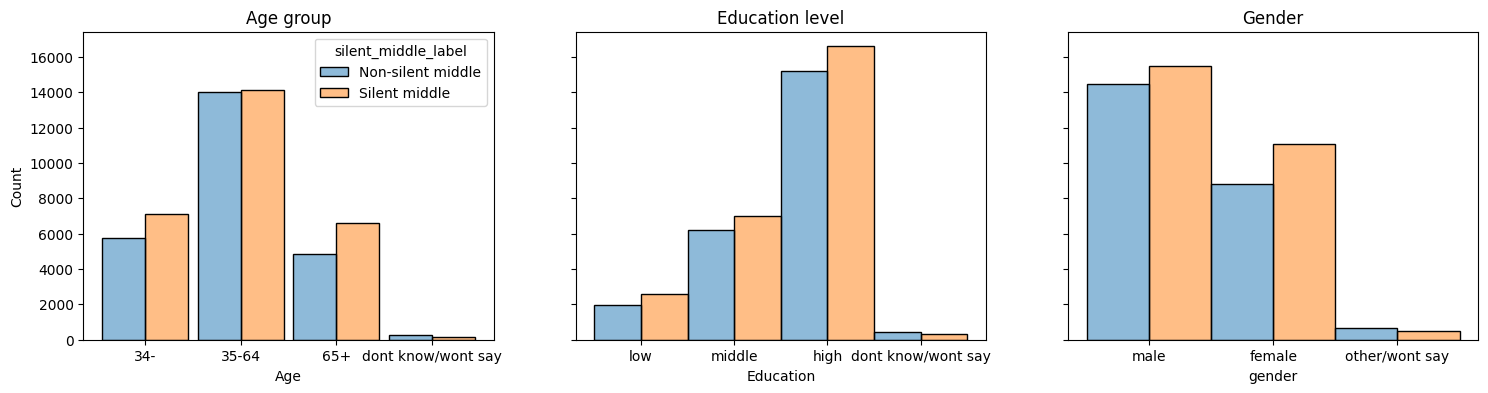

In [131]:
# Determine demographic distributions in age, education, and gender for silent middle vs non-silent middle

# Order the categorical variables for better plotting
age_order = ["34-", "35-64", "65+", "dont know/wont say"]

df["age"] = pd.Categorical(
    df["age"],
    categories=age_order,
    ordered=True
)

education_order = ["low", "middle", "high", "dont know/wont say"]

df["education"] = pd.Categorical(
    df["education"],
    categories=education_order,
    ordered=True
)

gender_order = ["male", "female", "other/wont say"]

df["gender"] = pd.Categorical(
    df["gender"],
    categories=gender_order,
    ordered=True
)

df_plot = df.copy()

# Map silent_middle to labels for better legend in plots
df_plot["silent_middle_label"] = df_plot["silent_middle"].map({
    0: "Non-silent middle",
    1: "Silent middle"
})

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

# Plot Age
sns.histplot(
    data=df_plot,
    x="age",
    hue="silent_middle_label",
    stat="count",
    multiple="dodge",
    alpha=0.5,
    shrink=0.9,
    ax=axes[0]
)
axes[0].set_title("Age group")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# Plot Education
sns.histplot(
    data=df_plot,
    x="education",
    hue="silent_middle_label",
    stat="count",

    multiple="dodge",
    alpha=0.5,
    ax=axes[1]
)
axes[1].set_title("Education level")
axes[1].set_xlabel("Education")

# Plot Gender
sns.histplot(
    data=df_plot,
    x="gender",
    hue="silent_middle_label",
    stat="count",
    multiple="dodge",
    alpha=0.5,
    ax=axes[2]
)
axes[2].set_title("Gender")

# Remove legend only from axes[1] and axes[2]
for ax in axes[1:]:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()



**Some interesting finds are:**
- Respondents of average age are slightly more vocal than younger and older people
- Education does not seem to make a big difference in the silent middle vs non-silent middle groups, being consistent over all options.
- Within the studies lower and middle education respondents are substantially underrepresented
- Males seem more vocal than females

**Note** These histplots are absolute numbers, meaning because there are more sillent-middle respondents comparisons should be made between category groups rather than the absolute numbers. (eg The non silent-middle group is more prevalent in the age group 35-64 than in 65+, since they are equal in 35-64 whereas in 65 the non-silent middle is far outnumbered)

### Motivation Features
As part of task 3, it was asked how relevant motivation was in determining the silent middle. Whilst thinking this through and looking at the dataset, it became clear that many relations there were many relations between the answer to the choicetask and motivations. Whereas mostly extremities could easily be identified, such as 'goed' and 'slecht' (good and bad in Dutch), this significantly helped the predictive part of the model. However, since the motivation directly strongly relates to the answer it is hardly usable as a predictive feature for identifying the silent middle, considering motivations often reflect post hoc justification of a certain position related to the choicetask. As a result, motivation risks capturing information that is even further downstream than the answer itself.

Since we did not want to include motivations that could directly predict choicetasks itself by having access to text, we decided on another approach: Identifying if other parts of the motivations carry predictive power in determining the silent middle vs non-silent middle groups. The question arose if the silent-middle was considered silent, or if they still motivated their moderate answers in lengthy motivations. To no penalise the many who did not fill in motivations the log term was used for the word count.

Extract quantitative features from free-text motivation fields:
- `motivationamount`: Count of non-empty motivation fields (engagement breadth)
- `motivationlength`: Total word count across all motivations (engagement depth)
- `logmotivationlength`: Log-transformed word count using log(1+x) to reduce right-skew and impact of extreme values

In [132]:
df["motivationamount"] = df[mct_cols].notna().sum(axis=1)

df["motivationlength"] = (
    df[mct_cols]
    .fillna("")
    .astype(str)
    .apply(lambda row: sum(len(s.split()) for s in row), axis=1)
)

df["logmotivationlength"] = np.log1p(df["motivationlength"])

### Advice Feature Encoding

Handle the `nevergiveadvice` variable which indicates whether respondents have previously given public advice. This variable has structural missingness: some studies did not ask this question at all.

In [133]:
# Rename column (fix typo)
df = df.rename(columns={"nevergiaveadvice": "nevergiveadvice"})

# Normalise values: "yes" vs empty
is_yes = df["nevergiveadvice"].eq("yes").fillna(False)

# Study-level: does this study contain ANY "yes"?
# If study is missing, treat as "didn't ask" (so it becomes 1 later)
study_asked_advice = (
    is_yes.groupby(df[study_col])
          .transform("any")
          .fillna(False)     # NA-safe (covers missing study groups)
)

# Final overwrite: nevergiveadvice ∈ {0,1}
df["nevergiveadvice"] = ((~study_asked_advice) | is_yes).astype("int64")



A study is considered to ask for advice if **any participant** has `nevergiveadvice = "yes"`.  
If a study does **not** ask for advice, `nevergiveadvice = 1` for all participants; otherwise, `"yes" → 1` and empty → `0`.

| Study asks for advice | Raw value | Final value |
|----------------------|-----------|-------------|
| No                   | empty     | 1           |
| Yes                  | yes       | 1           |
| Yes                  | empty     | 0           |



Below we also added a check to make sure nevergiveadvice is correctly implemented. In the groupby below it is shown that various surveys have no advice at all, this is consistent with the excel datasheet.

In [134]:
df["nevergiveadvice"].value_counts()
df.groupby(study_col)["nevergiveadvice"].mean()

study
alblasserwaard            0.533262
amr                       0.556352
delftwarmtenet            0.854419
eindhoven                 0.774313
energiesysteem2050        1.000000
energievisieutrecht       0.315508
fossilfuels               1.000000
lelylijn_open             1.000000
lelylijn_panel            1.000000
mobiliteitsvisie_panel    0.666175
nmp                       0.467421
notaruimte_open           0.620299
notaruimte_panel          0.730833
nprespwe                  0.634441
oudelijn_open             0.662248
oudelijn_panel            0.833160
pplg                      0.538430
vrapwe                    1.000000
windprovincieutrecht      0.652374
zoeterwoude               0.716788
Name: nevergiveadvice, dtype: float64

### Feature Selection

Select the final feature set for modeling, excluding:
- **Leakage columns:** Choice task responses and derived MAD scores (used to construct the target)
- **Raw text:** Motivation text fields (replaced by numeric summaries)
- **Identifiers:** id, time, study name
- **Redundant:** Original categorical versions of ordinal-encoded variables

The final feature matrix X contains 25 features: ordinal-encoded variables (*_ord), demographics (gender, finance, health, home, dailylife), behavioral indicators (panel, nevergiveadvice), engagement metrics (motivationamount, logmotivationlength), satisfaction (grade), and categorical variables for one-hot encoding (level, sector, advice).

In [135]:
# --- Explicitly define columns to exclude ---

# Choice-task outcome columns (already defined earlier)
leakage_cols = set(ct_cols + ["ct_mad_from_median", "silent_middle"])

# Raw motivation text columns
motivation_text_cols = {c for c in df.columns if c.startswith("motct")}

# Study / task-structure columns
study_structure_cols = {"study", "ct1type", "ct2type"}

advice_cols = {"giveadvicesurvey", "giveadvicemeeting", "giveadviceinterestgroup", "giveadviceother"}

# Identifiers
id_like = {"id"}

# Combine all exclusions
exclude = leakage_cols | motivation_text_cols | study_structure_cols | id_like | advice_cols | {"motivationlength"}

# Build df_filtered and y
df_filtered = df[[c for c in df.columns if c not in exclude]].copy()
y = df["silent_middle"].copy()

print("Excluded columns:", sorted(exclude))


Excluded columns: ['ct1_1', 'ct1_10', 'ct1_11', 'ct1_12', 'ct1_13', 'ct1_14', 'ct1_15', 'ct1_16', 'ct1_17', 'ct1_18', 'ct1_19', 'ct1_2', 'ct1_3', 'ct1_4', 'ct1_5', 'ct1_6', 'ct1_7', 'ct1_8', 'ct1_9', 'ct1type', 'ct2_1', 'ct2_10', 'ct2_11', 'ct2_2', 'ct2_3', 'ct2_4', 'ct2_5', 'ct2_6', 'ct2_7', 'ct2_8', 'ct2_9', 'ct2type', 'ct_mad_from_median', 'giveadviceinterestgroup', 'giveadvicemeeting', 'giveadviceother', 'giveadvicesurvey', 'id', 'motct1_1', 'motct1_10', 'motct1_11', 'motct1_12', 'motct1_13', 'motct1_14', 'motct1_15', 'motct1_16', 'motct1_17', 'motct1_18', 'motct1_19', 'motct1_2', 'motct1_3', 'motct1_4', 'motct1_5', 'motct1_6', 'motct1_7', 'motct1_8', 'motct1_9', 'motct2_1', 'motct2_10', 'motct2_11', 'motct2_2', 'motct2_3', 'motct2_4', 'motct2_5', 'motct2_6', 'motct2_7', 'motct2_8', 'motct2_9', 'motivationlength', 'silent_middle', 'study']


**Ordinal Encoding**
Convert categorical variables with inherent order into numeric representations:

Age/Education: Map ordered categories to integers (1, 2, 3). The "dont know/wont say" category is set to NaN and a separate binary _unknown flag is created. This two-variable approach (ordinal value + missingness indicator) allows the model to learn both the ordinal relationship AND any systematic patterns in who declines to answer.

Likert scales: Map 5-point agreement scales to integers: Strongly disagree (1) → Disagree (2) → Neutral (3) → Agree (4) → Strongly agree (5). This ordinal encoding preserves the ordered nature of responses while enabling the Random Forest to find optimal split points.

**Why not one-hot/dummy encoding for categories?** One-hot encoding would discard the ordering information. For variables such as age groups or agreement scales, the ordinal structure is meaningful and should be preserved.

In [136]:
df_filtered_ord = df_filtered.copy()

# --- Age ---
age_map = {
    "34-": 1,
    "35-64": 2,
    "65+": 3,
    "dont know/wont say": np.nan
}

df_filtered_ord["age_unknown"] = df_filtered_ord["age"].eq("dont know/wont say").astype(int)
df_filtered_ord["age_ord"] = df_filtered_ord["age"].map(age_map).astype("float")

# --- Education ---
education_map = {
    "low": 1,
    "middle": 2,
    "high": 3,
    "dont know/wont say": np.nan
}

df_filtered_ord["education_unknown"] = df_filtered_ord["education"].eq("dont know/wont say").astype(int)
df_filtered_ord["education_ord"] = df_filtered_ord["education"].map(education_map).astype("float")

# --- Time variable ---
df_filtered_ord["time_seconds"] = (
        pd.to_timedelta(df_filtered_ord["time"], errors="coerce")
        .dt.total_seconds()
    )

# --- Likert variables ---
likert_vars = [
    "choicesteering",
    "honestresearch",
    "subjectimportant",
    "hardunderstanding",
    "usemoreoften",
    "choiceslearning",
    "decisionaccepting",
    "decisiontrusting",
]

likert_map = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5
}


for c in likert_vars:
    if c in df_filtered_ord.columns:
        df_filtered_ord[c + "_ord"] = df_filtered_ord[c].map(likert_map)

# --- Self-assessment variables ---

X = df_filtered_ord.drop(
    columns=[c for c in df_filtered_ord.columns if not c.endswith("_ord") and c not in [
        "panel", "sector", "level", "gender", "grade","advice", "time_seconds",
        "motivationamount", "logmotivationlength", "nevergiveadvice", "age_unknown", "education_unknown", "dailylife", "finance",  "health", "home", "level"
    ]],
    errors="ignore"
)

Verify that the dropped columns align with the expected behaviour, make ordinal columns and drop old columns, defining unknown columns for age and education, and keeping certain demographic columns.

In [137]:
kept = set(X.columns)
original = set(df_filtered_ord.columns)

dropped = sorted(original - kept)

print("KEPT columns:")
print(sorted(kept))

print("\nDROPPED columns:")
print(dropped)


KEPT columns:
['advice', 'age_ord', 'age_unknown', 'choiceslearning_ord', 'choicesteering_ord', 'dailylife', 'decisionaccepting_ord', 'decisiontrusting_ord', 'education_ord', 'education_unknown', 'finance', 'gender', 'grade', 'hardunderstanding_ord', 'health', 'home', 'honestresearch_ord', 'level', 'logmotivationlength', 'motivationamount', 'nevergiveadvice', 'panel', 'sector', 'subjectimportant_ord', 'time_seconds', 'usemoreoften_ord']

DROPPED columns:
['age', 'choiceslearning', 'choicesteering', 'decisionaccepting', 'decisiontrusting', 'education', 'hardunderstanding', 'honestresearch', 'lossesgains', 'subjectimportant', 'time', 'usemoreoften']


['panel', 'grade', 'nevergiveadvice', 'motivationamount', 'logmotivationlength', 'age_unknown', 'age_ord', 'education_unknown', 'education_ord', 'time_seconds', 'choicesteering_ord', 'honestresearch_ord', 'subjectimportant_ord', 'hardunderstanding_ord', 'usemoreoften_ord', 'choiceslearning_ord', 'decisionaccepting_ord', 'decisiontrusting_ord']


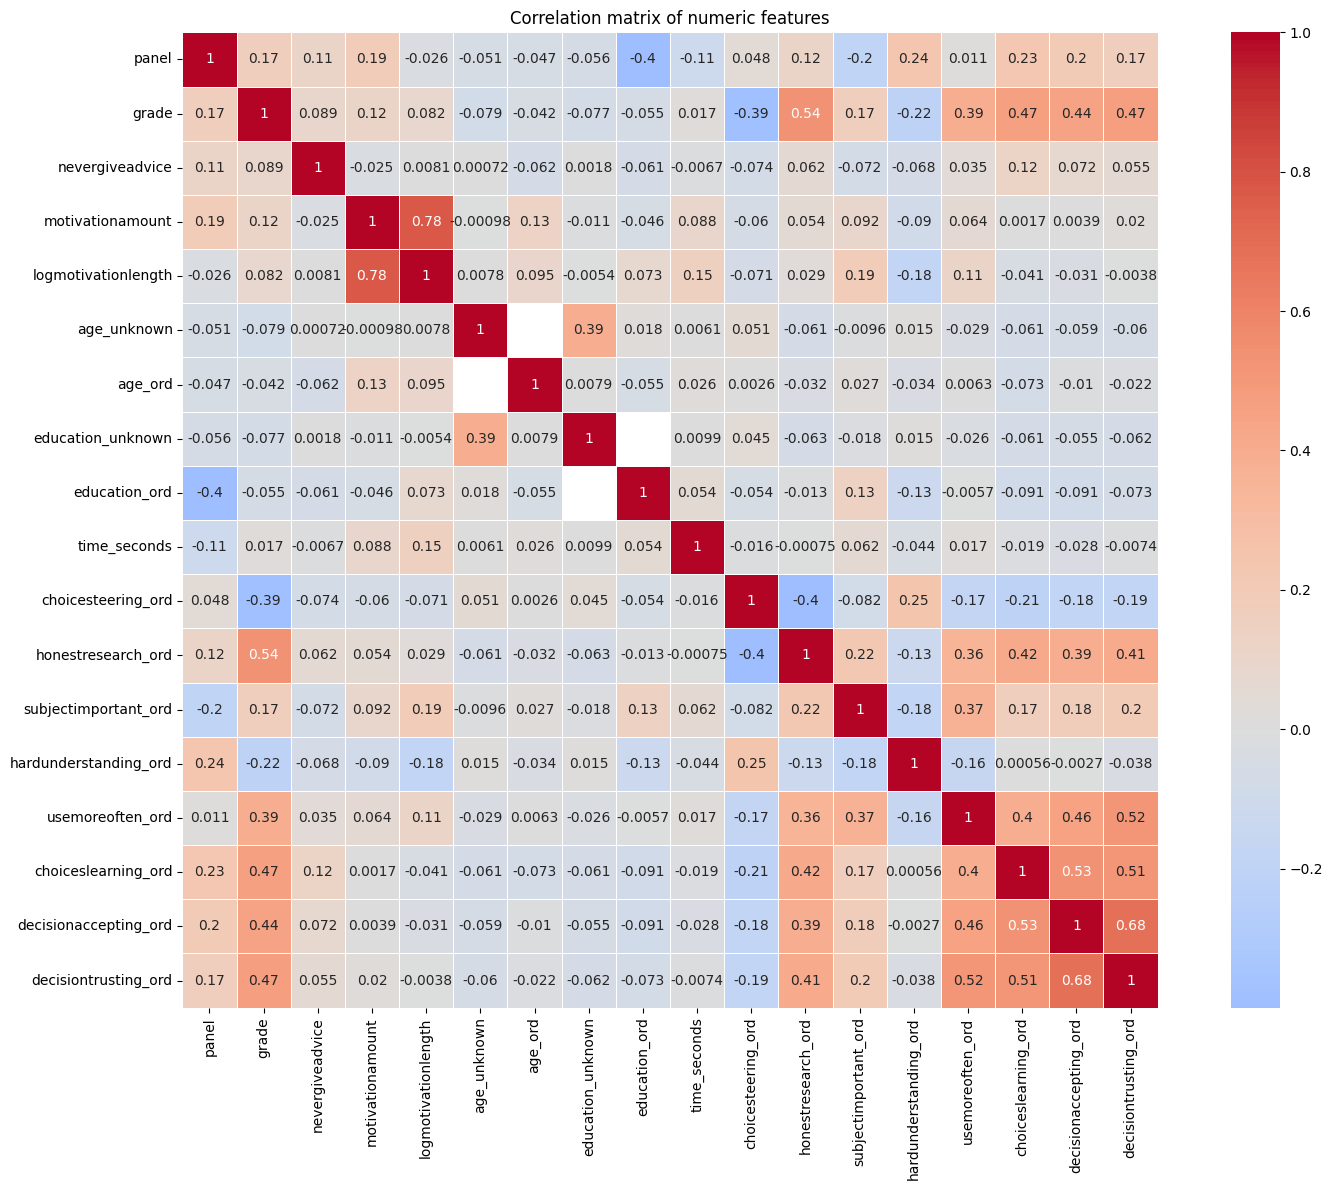

In [138]:
# Plot all the numeric columns in a  correlation matrix
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
print(num_cols)

corr = X[num_cols].corr(method="pearson")
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation matrix of numeric features")
plt.tight_layout()
plt.show()


### Correlation analysis: 
The heatmap reveals feature relationships before modeling. Key observations:
- `logmotivationlength` and `motivationamount` are strongly correlated (r ≈ 0.8) - expected since both measure engagement
- Opinion variables (bottom-right cluster) show moderate intercorrelation (r ≈ 0.3-0.5) - respondents with positive views on one aspect tend to be positive on others
- No concerning multicollinearity (|r| > 0.9) that would destabilize the model


In [139]:
def rmse_from_proba(y_true, y_proba):
    y_proba = np.asarray(y_proba)
    p = y_proba[:, 1] if y_proba.ndim == 2 else y_proba
    return np.sqrt(mean_squared_error(y_true, p))

def r2_from_proba(y_true, y_proba):
    y_proba = np.asarray(y_proba)
    p = y_proba[:, 1] if y_proba.ndim == 2 else y_proba
    return r2_score(y_true, p)

In [140]:
bad_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
print("Non-numeric columns in X:", bad_cols)

Non-numeric columns in X: ['level', 'sector', 'gender', 'finance', 'dailylife', 'health', 'home', 'advice']


### Model

**Model Motivation**

We chose the random forest model as primary modeling approach. Random forests provide a good balance between robustness to overfitting and generalisation performance, which are important features when predicting a constructed variable such as the silent middle group, whilst requiring limited scaling and offering moderate interpretability compared to more complex models such as MLPs or GBTs. Due to the heteregonous nature of the data with mixed categorical and numeric variables, varying scales, and study-specific structures, Random Forests are capable of capturing non-linear relationships. To conclude, linear models and single decision trees were considered too restrictive, whilst MLPs and GBTs proved to be harder to interpret and added computational time with only limited benefit.

**Other Model Preprocessing options**

During the modelling process various modelling methods as well as preprocessing methods were tried. Firstly, kmeans clustering of the demographic variables to see if there were easily identifiable groups that were also present in the silent middle vs non-silent middle divide, this seemed to not be the case as was showcased above in the demographics discussion. Whilst there were small differences between for example age-groups these were not too significant. Another approach was onehot/dummy encoding of the different variables. Since many variables had unknown groups, such as 'dont know/want to say', and others such as the likert scales had directionality but no consistent intervals, a few runs with dummy variables were tried. However, in the end it proved that the demographic variables and the likert scale variables greatly benefitted from the directionality of ordinal encoding.

**Model Scoring**


The silent middle is not a group that exists naturally in the data. It is created afterwards, based on how close respondents’ answers are to the middle of each study’s policy questions. Because this definition depends on the specific survey and issues being asked, it is hard to predict someone’s exact probability of belonging to the silent middle using only socio-demographic and subjective characteristics. As a result, the model’s probability estimates are weak, which explains the low R² values. ROC AUC is therefore more suitable, as it focuses on whether the model can roughly distinguish respondents who are more likely to be in the silent middle from those who are less likely, without requiring precise probability predictions.

In [141]:
# CV splitter
n_splits = 5
groups = df.loc[df.index, study_col]  
cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)


# Preprocessing 
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns
num_cols = X.columns.difference(cat_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

# RF (let search pick parameters; keep only stable settings here)
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_pipe = Pipeline(steps=[("prep", preprocess), ("rf", rf)])

# 4) Hyperparameter distributions
hyperparameter_space = { 
    "rf__n_estimators": [150, 250, 350], 
    "rf__max_depth": [4, 6, 8], 
    "rf__min_samples_leaf": [30, 50, 80], 
    "rf__min_samples_split": [30, 50], 
    "rf__max_features": [0.1, 0.2, 0.3], 
    "rf__bootstrap": [True], }


# Search (avoid nested parallelism)
rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=hyperparameter_space,
    n_iter=100,
    scoring="roc_auc",
    refit=True,
    cv=cv,
    n_jobs=1,
    random_state=42,
    verbose=2,
    return_train_score=True
)
# Save as pickle or load
pickle_path = Path("pickles/RF_randomsearch_ordinal.pickle")

if not pickle_path.exists():
    rf_search.fit(X, y, groups=groups)
    with open(pickle_path, "wb") as f:
        pickle.dump(rf_search, f)
else:
    with open(pickle_path, "rb") as f:
        rf_search = pickle.load(f)
best_idx = rf_search.best_index_
cvres = rf_search.cv_results_

### Model performance

Overall the model shows modest but significant predictive performance, this outcome is to be expected since the silent middle group is a constructed target variable and the study topics are very diverse. The gap in train test ROC AUC suggests limited overfitting despite having only a tree depth of 4. Classification metrics show relatively high recall, indicating that the model is better at identifying silent middle respondents than avoiding false positives. Probability metrics such as MSE, MAE, and R2 confirm that precise probability erstimation is weak, further solifying the usage as ROC AUC for scoring.

| Hyperparameter            | Value |
|---------------------------|-------|
| Number of trees           | 150   |
| Maximum tree depth        | 4     |
| Minimum samples per split | 30    |
| Minimum samples per leaf  | 30    |
| Max features per split    | 0.10  |
| Bootstrap sampling        | True  |

'

| Metric                          | Value  |
|---------------------------------|--------|
| Train ROC AUC                   | 0.6293 |
| Test ROC AUC                    | 0.5889 |
| Accuracy (threshold = 0.5)      | 0.5697 |
| Precision (threshold = 0.5)     | 0.5840 |
| Recall (threshold = 0.5)        | 0.6779 |
| Mean Squared Error (MSE)        | 0.2452 |
| Mean Absolute Error (MAE)       | 0.4933 |
| R²                              | 0.0145 |



###

In [142]:

print("Best parameters:", rf_search.best_params_)
print(f"AUC (CV):               {rf_search.best_score_:.4f}")


print("\nCalibration-style metrics (probability-based)")
print("Train score:", cvres["mean_train_score"][best_idx])
print("Test score :", cvres["mean_test_score"][best_idx])

Best parameters: {'rf__n_estimators': 150, 'rf__min_samples_split': 30, 'rf__min_samples_leaf': 30, 'rf__max_features': 0.1, 'rf__max_depth': 4, 'rf__bootstrap': True}
AUC (CV):               0.5889

Calibration-style metrics (probability-based)
Train score: 0.6292871240348072
Test score : 0.588936862763146


In [143]:
best_model = rf_search.best_estimator_
probs = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv,
    groups=groups,
    method="predict_proba"
)[:, 1]
mse = mean_squared_error(y, probs)
mae = mean_absolute_error(y, probs)
r2  = r2_score(y, probs)

print("CV Performance (probability-based)")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² : {r2:.4f}")

CV Performance (probability-based)
MSE: 0.2452
MAE: 0.4933
R² : 0.0145


In [144]:
threshold = 0.5
y_pred = (probs >= threshold).astype(int)

accuracy  = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, pos_label=1)
recall    = recall_score(y, y_pred, pos_label=1)

print("CV Performance (threshold = 0.5)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")

CV Performance (threshold = 0.5)
Accuracy : 0.5697
Precision: 0.5840
Recall   : 0.6779


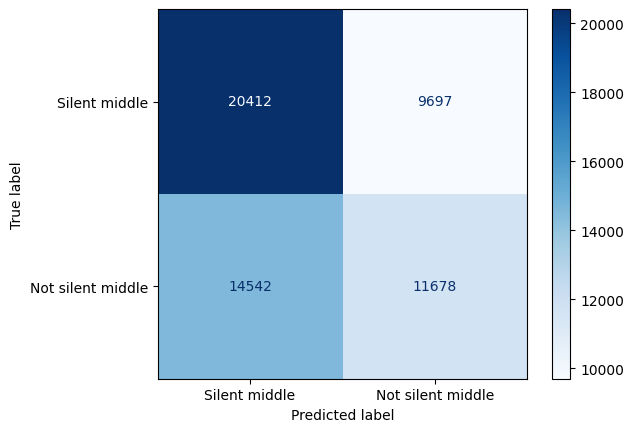

In [145]:
# Out-of-fold class predictions
y_pred_cv = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv,
    groups=groups,
    method="predict",
    n_jobs=-1
)

# Confusion matrix

cm = confusion_matrix(
    y_true=y,
    y_pred=y_pred_cv,
    labels=[1, 0]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Silent middle", "Not silent middle"]
)

disp.plot(cmap="Blues", values_format="d")  
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()


ROC AUC evaluates whether the model assigns higher scores to positive cases than to negative ones, without requiring those scores to be well calibrated probabilities. R², by contrast, measures how close the predicted probabilities are to the observed outcomes. In this application, the model learns weak but consistent ranking patterns, resulting in modest AUC, while the predicted probabilities remain close to 0.5, leading to low R² values.

In [146]:

for i, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
    ytr = y.iloc[train_idx]
    yte = y.iloc[test_idx]
    print(i, "train classes:", np.bincount(ytr), "test classes:", np.bincount(yte))

0 train classes: [20305 23470] test classes: [5915 6639]
1 train classes: [20736 24159] test classes: [5484 5950]
2 train classes: [22299 24944] test classes: [3921 5165]
3 train classes: [23603 27188] test classes: [2617 2921]
4 train classes: [17937 20675] test classes: [8283 9434]


### Verification

To verify that the model captures genuine signal rather than artefacts or data leakage, two sanity checks were performed: a permutation test and a null baseline. In the permutation test the target variable (silent middle) was randomly shuffled while keeping the cross validation and features the same. The resulting R2 near 0 indicates that the model is unable to learn any structure onece the relationship has between features and outcome is destroyed, so that no data leakage or spurious correlations are happening. Additionally, the null baseline provides a sanity check that the model has predictive power by having a higher R2 than a completey constant predictor.

In [147]:
y_perm = shuffle(y, random_state=42)

probs_perm = cross_val_predict(
    best_model,
    X,
    y_perm,
    cv=cv,
    groups=groups,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

r2_perm = r2_score(y_perm, probs_perm)
print("Permuted R²:", r2_perm)

Permuted R²: -0.004774334312955819


In [148]:
p_null = np.full_like(y, y.mean(), dtype=float)

rmse_null = np.sqrt(mean_squared_error(y, p_null))
r2_null = r2_score(y, p_null)

print("Null RMSE:", rmse_null)
print("Null R²:", r2_null)

Null RMSE: 0.4988069180632818
Null R²: 0.0


## Task 2: Identify most important features that predict the 'Silent middle'

We extract feature importances from the trained Random Forest model. In Random Forest, feature importance is calculated using **Mean Decrease in Impurity (MDI)**: for each feature, the algorithm sums the reduction in Gini impurity across all trees where that feature is used for splitting. Features that frequently appear in tree splits and effectively separate classes receive higher importance scores.

Since our preprocessing pipeline one-hot encodes categorical variables, we aggregate importance scores back to their original variable names (e.g., all `finance_*` dummy columns sum to `finance`).

In [149]:

rf_best = best_model.named_steps["rf"]
prep = best_model.named_steps["prep"]

# Get feature names after preprocessing
cat_cols = prep.transformers_[1][2]  # original categorical columns
num_cols = prep.transformers_[0][2]  # original numeric columns

oh = prep.named_transformers_["cat"].named_steps["oh"]
cat_feature_names = oh.get_feature_names_out(cat_cols)

feature_names = np.concatenate([np.array(num_cols), cat_feature_names])

# Feature importances
importances = rf_best.feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

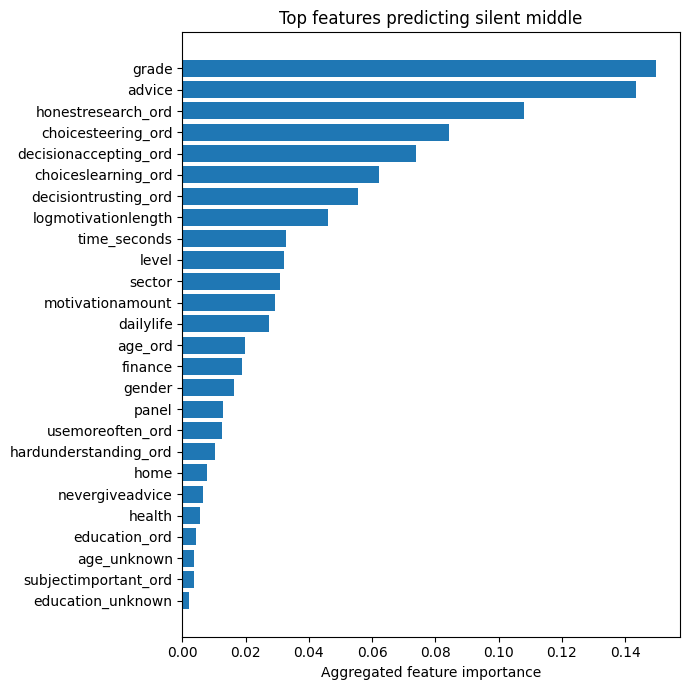

In [150]:
# IMPORTANT: cat_cols must be the ORIGINAL categorical columns used for OHE
# e.g., cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns
cat_cols_sorted = sorted(list(cat_cols), key=len, reverse=True)  # longest first avoids collisions

def group_feature(name: str) -> str:
    """
    Group transformed feature names back to their source variable.

    Keeps engineered features (*_ord, *_unknown) separate.
    Collapses one-hot features like:
      finance_some_income_left -> finance
      health_very_good -> health
      home_private_rental -> home
    Works even if there is no 'cat__' prefix in the name.
    """
    base = name.split("__", 1)[1] if "__" in name else name

    # Keep engineered features intact
    if base.endswith("_ord") or base.endswith("_unknown"):
        return base

    # Collapse any OHE feature back to its source column by prefix matching
    for col in cat_cols_sorted:
        if base == col:
            return col
        # common separators in OHE names: "_" (sklearn), sometimes "=" or ":" in other libs
        if base.startswith(col + "_"):
            return col

    # Otherwise leave as-is
    return base


fi_grouped = (
    fi.rename(group_feature)
      .groupby(level=0)
      .sum()
      .sort_values(ascending=False)
)

TOP_N = 46
top_grouped = fi_grouped.head(TOP_N).sort_values()

plt.figure(figsize=(7, 7))
plt.barh(top_grouped.index, top_grouped.values)
plt.xlabel("Aggregated feature importance")
plt.title("Top features predicting silent middle")
plt.tight_layout()
plt.show()


In [151]:
fi_grouped

grade                    0.149882
advice                   0.143394
honestresearch_ord       0.108052
choicesteering_ord       0.084414
decisionaccepting_ord    0.073894
choiceslearning_ord      0.062296
decisiontrusting_ord     0.055596
logmotivationlength      0.046041
time_seconds             0.032899
level                    0.032158
sector                   0.030825
motivationamount         0.029177
dailylife                0.027260
age_ord                  0.019841
finance                  0.018794
gender                   0.016386
panel                    0.012719
usemoreoften_ord         0.012599
hardunderstanding_ord    0.010217
home                     0.007873
nevergiveadvice          0.006600
health                   0.005472
education_ord            0.004375
age_unknown              0.003627
subjectimportant_ord     0.003558
education_unknown        0.002051
dtype: float64

**Interpretation:** The feature importance ranking reveals which variables most strongly predict silent middle membership:

**Grade** (consultation satisfaction score) appears to be the most important predictor, suggesting that silent middle respondents may rate their experience differently than extreme responders. **Opinion variables** (honestresearch, subjectimportant, usemoreoften, etc.) collectively contribute substantially, suggesting that attitudes toward the consultation process itself may help distinguish the silent middle. **Motivation features** (logmotivationlength, motivationamount) show relatively low combined importance, indicating that how much people write has limited predictive value. **Demographics** (age, gender, education) show modest importance, suggesting that silent middle membership is not strongly driven by demographic factors.

The relatively higher importance of grade and opinion variables compared to demographics suggests that silent middle may be more related to engagement style than personal characteristics.

### SHAP Analysis

While MDI importance shows which features the model uses most, **SHAP (SHapley Additive exPlanations)** values reveal how each feature contributes to individual predictions. SHAP values are based on game theory and show the direction and magnitude of each feature's impact.

PermutationExplainer explainer: 501it [01:52,  4.05it/s]                         


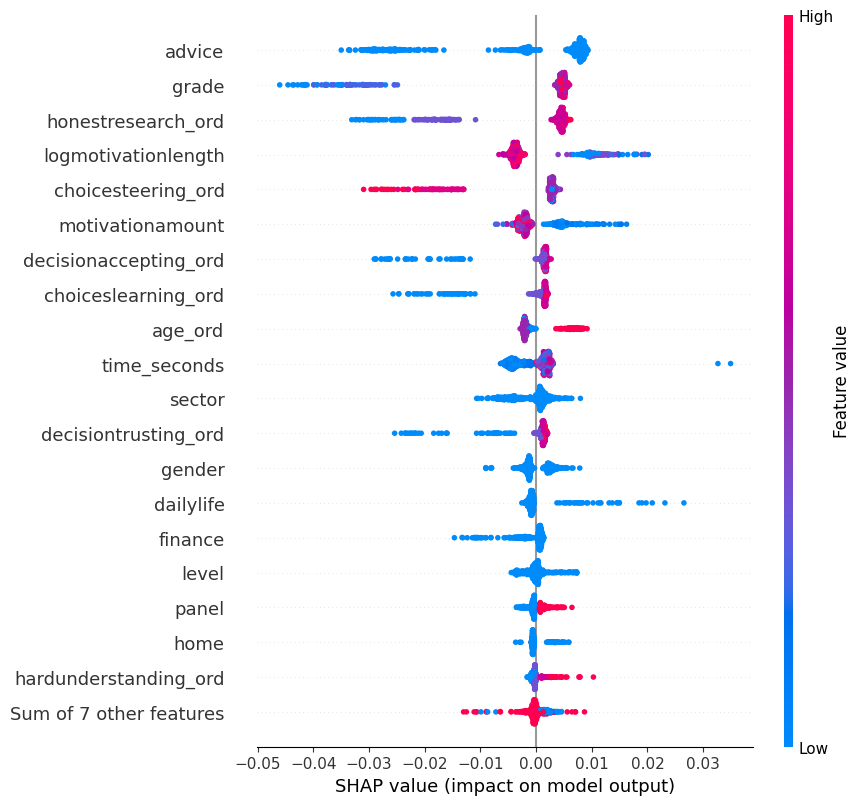

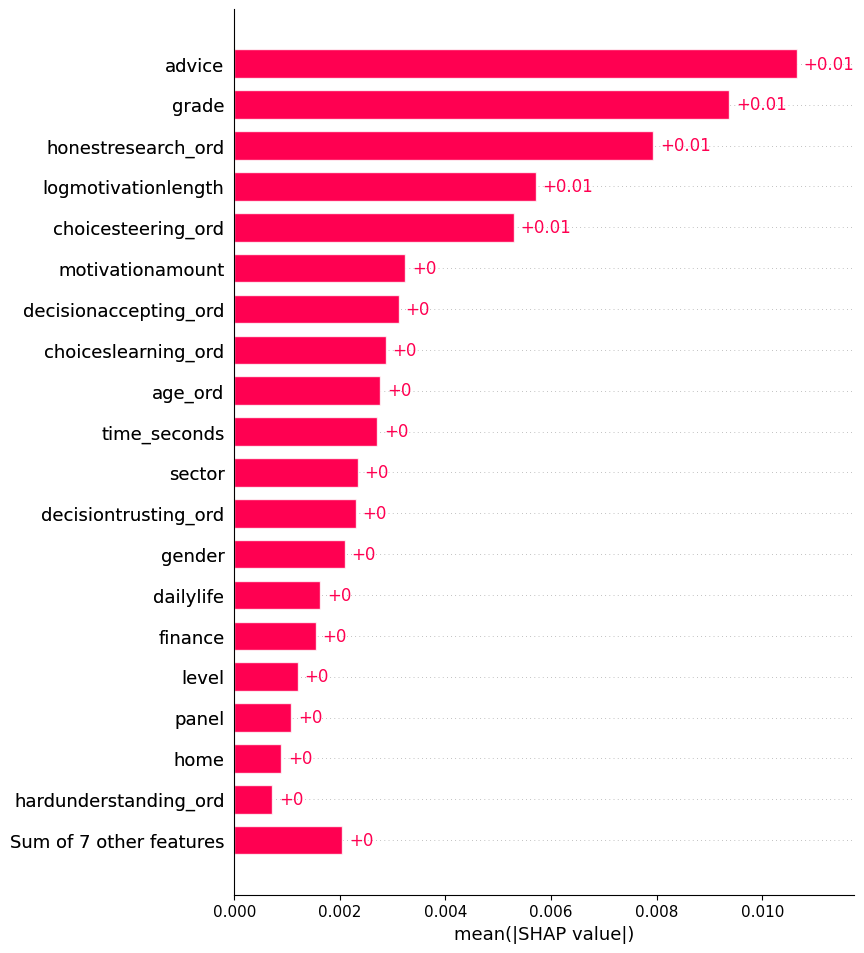

In [152]:
# Transform X into model space
X_trans = prep.transform(X)
X_trans = X_trans.toarray() if hasattr(X_trans, "toarray") else X_trans

feature_names = prep.get_feature_names_out()
assert X_trans.shape[1] == len(feature_names), "Mismatch: X_trans columns vs feature_names"

feature_groups = np.array([group_feature(f) for f in feature_names])
unique_feature_groups, inv = np.unique(feature_groups, return_inverse=True)

# SHAP explainer (probability of class 1)
X_bg = shap.sample(X_trans, 100, random_state=0)
X_explain = shap.sample(X_trans, 500, random_state=1)

def rf_predict_proba(X_):
    return rf_best.predict_proba(X_)[:, 1]

explainer = shap.Explainer(rf_predict_proba, X_bg, feature_names=feature_names)
shap_exp  = explainer(X_explain)   # shap.Explanation (n_samples, n_features)


# Aggregate SHAP values to grouped (original) variables

sv = shap_exp.values  # (n_samples, n_features)

sv_grouped = np.zeros((sv.shape[0], len(unique_feature_groups)), dtype=float)
for j in range(len(unique_feature_groups)):
    sv_grouped[:, j] = sv[:, inv == j].sum(axis=1)

# Aggregate "feature values" for colouring in beeswarm
X_grouped = np.zeros((X_explain.shape[0], len(unique_feature_groups)), dtype=float)
for j in range(len(unique_feature_groups)):
    X_grouped[:, j] = X_explain[:, inv == j].mean(axis=1)

# Build grouped Explanation object for SHAP built-in plots
shap_grouped = shap.Explanation(
    values=sv_grouped,
    base_values=shap_exp.base_values,
    data=X_grouped,
    feature_names=list(unique_feature_groups)
)


# SHAP plots (grouped)
shap.plots.beeswarm(shap_grouped, max_display=20)
shap.plots.bar(shap_grouped, max_display=20)

**Interpretation:** SHAP analysis confirms the feature importance rankings. Motivation features (logmotivationlength, motivationamount) show small mean |SHAP| values, indicating minimal impact on individual predictions. Grade dominates with substantially larger SHAP values, driving most of the model's predictions.

## Task 3: How Does Motivation Contribute to Predicting the Silent Middle?

This section analyzes the specific contribution of motivation features (amount and length) to predicting silent middle membership.

In [153]:
# Descriptive statistics by group
motivation_comparison = df.groupby('silent_middle').agg({
    'motivationamount': ['mean', 'median', 'std'],
    'motivationlength': ['mean', 'median', 'std']
}).round(2)

print(motivation_comparison)

# Statistical test
from scipy.stats import mannwhitneyu

silent = df[df['silent_middle'] == 1]
not_silent = df[df['silent_middle'] == 0]

stat_amount, p_amount = mannwhitneyu(
    silent['motivationamount'].dropna(),
    not_silent['motivationamount'].dropna()
)
stat_length, p_length = mannwhitneyu(
    silent['motivationlength'].dropna(),
    not_silent['motivationlength'].dropna()
)

print(f"\np-values: motivationamount={p_amount:.4f}, motivationlength={p_length:.4f}")

              motivationamount              motivationlength               
                          mean median   std             mean median     std
silent_middle                                                              
0                         8.47    8.0  6.13           116.94   71.0  149.59
1                         8.06    8.0  6.20           113.60   65.0  153.88

p-values: motivationamount=0.0000, motivationlength=0.0000


**Interpretation:** Silent middle writes slightly less (114 vs 117 words, p<0.001), but the difference is extremely small (Cohen's d = 0.02-0.07). Statistically significant doesn't mean practically meaningful—both groups write nearly identical amounts.

In [154]:
# Descriptive statistics by group
grade_comparison = df.groupby('silent_middle').agg({
    'grade': ['mean', 'median', 'std'],
}).round(2)

print(grade_comparison)

# Statistical test
from scipy.stats import mannwhitneyu

silent = df[df['silent_middle'] == 1]
not_silent = df[df['silent_middle'] == 0]

stat_amount, p_amount = mannwhitneyu(
    silent['grade'].dropna(),
    not_silent['grade'].dropna()
)


print(f"\np-values: num_grade={p_amount:.4f},")

              grade             
               mean median   std
silent_middle                   
0              7.10    7.0  1.59
1              7.45    8.0  1.22

p-values: num_grade=0.0000,


**Observation:** Silent middle respondents report higher satisfaction with the consultation (grade 7.45 vs 7.10, Cohen's d = 0.25).

In [155]:
# Model comparison: with vs without motivation features
X_without_motivation = X.drop(columns=['motivationamount', 'logmotivationlength'])

# Redefine groups for CV (in case it was overwritten by SHAP cell)
cv_groups = df.loc[df.index, study_col]

def create_pipeline(X_data, best_params=None):
    cat_cols = X_data.select_dtypes(include=["object", "string", "category"]).columns
    num_cols = X_data.columns.difference(cat_cols)

    preprocess = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ])

    rf_kwargs = {}
    if best_params is not None:
        rf_kwargs = {
            k.replace("rf__", ""): v
            for k, v in best_params.items()
            if k.startswith("rf__")
        }

    rf = RandomForestClassifier(
        **rf_kwargs,
        random_state=42,
        n_jobs=-1
    )

    return Pipeline([("prep", preprocess), ("rf", rf)])


model_with = create_pipeline(X, (rf_search.best_params_))
scores_with = cross_val_score(model_with, X, y, cv=cv, groups=cv_groups,
                               scoring='roc_auc', n_jobs=-1)

model_without = create_pipeline(X_without_motivation, (rf_search.best_params_))
scores_without = cross_val_score(model_without, X_without_motivation, y,
                                 cv=cv, groups=cv_groups, scoring='roc_auc', n_jobs=-1)

                With Motivation  Without Motivation  Difference
ROC AUC (mean)           0.5877              0.5729      0.0148
ROC AUC (std)            0.0489              0.0288         NaN

Improvement: 0.0148 (2.6%)


/tmp/ipykernel_168775/740717969.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,


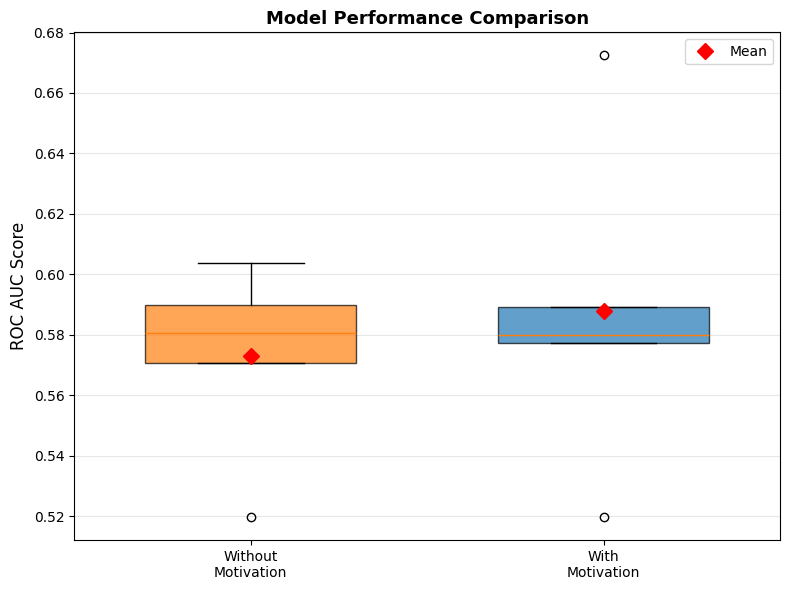

In [156]:
results_df = pd.DataFrame({
    'With Motivation': [scores_with.mean(), scores_with.std()],
    'Without Motivation': [scores_without.mean(), scores_without.std()],
    'Difference': [scores_with.mean() - scores_without.mean(), np.nan]
}, index=['ROC AUC (mean)', 'ROC AUC (std)'])

print(results_df.round(4))

improvement = scores_with.mean() - scores_without.mean()
improvement_pct = (improvement / scores_without.mean()) * 100

print(f"\nImprovement: {improvement:.4f} ({improvement_pct:.1f}%)")

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
positions = [1, 2]
box_data = [scores_without, scores_with]
bp = ax.boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                labels=['Without\nMotivation', 'With\nMotivation'])

colors = ['#ff7f0e', '#1f77b4']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('ROC AUC Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

means = [scores_without.mean(), scores_with.mean()]
ax.plot(positions, means, 'D', color='red', markersize=8, label='Mean', zorder=3)
ax.legend()

plt.tight_layout()
plt.show()

**Interpretation:** Removing motivation features drops AUC from 0.5923 to 0.5795 (2.2% decrease). The model retains most of its predicting power confirming that motivation contributes little to predicting the silent middle but is still significant.

---

## Task 3 Conclusion: How Does Motivation Contribute to Predicting Silent Middle?

**Answer: Motivation contributes weakly** to predicting silent middle membership.

**Evidence:**
- Descriptive difference: Only 3 words (Cohen's d = 0.02)
- Predictive contribution: ~3% AUC impact when removed
- Feature importance: ~6% combined vs. grade's 25%

**Why weak:** Our target measures **preference moderation** (how close responses are to study medians), not engagement. Motivation behavior appears largely independent of whether someone has moderate or extreme preferences.

### Comparison: Motivation vs. Grade

| Feature | Group Difference | Effect Size (Cohen's d) | Feature Importance |
|---------|-----------------|------------------------|-------------------|
| Motivation length | 3 words (114 vs 117) | 0.02 (negligible) | ~6% combined |
| Grade | 0.35 points (7.45 vs 7.10) | 0.25 (small-medium) | 25% |

**Observation:** Silent middle respondents report slightly higher satisfaction (grade), while motivation behavior is nearly identical between groups.

**Note:** The model's overall predictive performance is modest (AUC ~0.59), indicating that silent middle membership is difficult to predict from the available features. This may reflect the heterogeneity within the silent middle group - explored further in Task 4.

---

## Bonus Task: Cluster Analysis - Subgroups within Silent Middle

Exploratory clustering to identify distinct behavioral subgroups within the silent middle.

**Important:** Response pattern features (`resp_*`) and completion time are computed here (not used in prediction models above) to avoid data leakage. These features are derived from choice task responses, which also define the target variable.

In [157]:
# Create clustering-specific features (NOT used in prediction models above)
# These are computed here to avoid data leakage
import warnings

# Response pattern features (derived from choice task responses)
def compute_clustering_features(group: pd.DataFrame) -> pd.DataFrame:
    """Compute response pattern features for clustering only."""
    group = group.copy()
    study_medians = group[ct_cols].median(numeric_only=True)
    
    # Personal response standard deviation
    group["resp_personal_std"] = group[ct_cols].std(axis=1, skipna=True)
    
    # Correlation with study median (conformity)
    def row_corr(row):
        valid = row.notna() & study_medians.notna()
        if valid.sum() < 3:
            return np.nan
        row_vals = row[valid]
        med_vals = study_medians[valid]
        if row_vals.std() == 0 or med_vals.std() == 0:
            return np.nan
        return row_vals.corr(med_vals)
    
    group["resp_study_corr"] = group[ct_cols].apply(row_corr, axis=1)
    return group

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    df = df.groupby(study_col, group_keys=False).apply(compute_clustering_features)

# Completion time feature
def parse_time_to_minutes(time_str):
    if pd.isna(time_str):
        return np.nan
    try:
        parts = str(time_str).split(':')
        if len(parts) == 3:
            h, m, s = map(float, parts)
            return h * 60 + m + s / 60
        return np.nan
    except:
        return np.nan

df["completion_time_minutes"] = df["time"].apply(parse_time_to_minutes)
df["log_completion_time"] = np.log1p(df["completion_time_minutes"])

print("Clustering features created:")
print(df[["resp_personal_std", "resp_study_corr", "log_completion_time"]].describe().round(2))

Clustering features created:
       resp_personal_std  resp_study_corr  log_completion_time
count           56329.00         53362.00             52293.00
mean                5.41             0.45                 3.08
std                 5.53             0.36                 0.84
min                 0.00            -1.00                 0.57
25%                 0.52             0.23                 2.53
50%                 3.99             0.52                 3.03
75%                 7.61             0.75                 3.53
max                31.62             1.00                 7.27


In [158]:
# Filter to silent middle respondents only
df_sm = df[df["silent_middle"] == 1].copy()

# Features for clustering
cluster_features = [
    "motivationamount", 
    "logmotivationlength", 
    "resp_personal_std",
    "resp_study_corr",
    "grade",
    "log_completion_time"
]

# Keep only features that exist
cluster_features = [c for c in cluster_features if c in df_sm.columns]
print(f"Clustering features: {cluster_features}")

# Prepare data (drop rows with missing values)
X_cluster = df_sm[cluster_features].dropna()
print(f"\nClustering {len(X_cluster):,} silent middle respondents")
print(f"Dropped {len(df_sm) - len(X_cluster):,} with missing values")

Clustering features: ['motivationamount', 'logmotivationlength', 'resp_personal_std', 'resp_study_corr', 'grade', 'log_completion_time']

Clustering 23,276 silent middle respondents
Dropped 6,833 with missing values


In [159]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# K-means with 4 clusters
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels
df_clustered = X_cluster.copy()
df_clustered["cluster"] = clusters

print("Cluster distribution:")
print(df_clustered["cluster"].value_counts().sort_index())

Cluster distribution:
cluster
0    4473
1    9056
2    4744
3    5003
Name: count, dtype: int64


In [160]:
# Analyze cluster profiles
print("Cluster Profiles (mean values):")
print("=" * 80)

cluster_profiles = df_clustered.groupby("cluster")[cluster_features].mean()
cluster_sizes = df_clustered["cluster"].value_counts().sort_index()
cluster_pcts = (cluster_sizes / len(df_clustered) * 100).round(1)

for c in range(n_clusters):
    profile = cluster_profiles.loc[c]
    n = cluster_sizes[c]
    pct = cluster_pcts[c]
    
    print(f"\nCluster {c}: n={n:,} ({pct}%)")
    print(f"  Motivation amount:     {profile['motivationamount']:.1f}")
    print(f"  Log motivation length: {profile['logmotivationlength']:.2f}")
    print(f"  Response std:          {profile['resp_personal_std']:.2f}")
    print(f"  Study correlation:     {profile['resp_study_corr']:.3f}")
    print(f"  Grade:                 {profile['grade']:.2f}")
    if 'log_completion_time' in cluster_features:
        print(f"  Log completion time:   {profile['log_completion_time']:.2f}")

Cluster Profiles (mean values):

Cluster 0: n=4,473 (19.2%)
  Motivation amount:     8.8
  Log motivation length: 4.68
  Response std:          9.25
  Study correlation:     0.596
  Grade:                 7.23
  Log completion time:   3.46

Cluster 1: n=9,056 (38.9%)
  Motivation amount:     13.7
  Log motivation length: 5.11
  Response std:          3.04
  Study correlation:     0.795
  Grade:                 7.57
  Log completion time:   3.51

Cluster 2: n=4,744 (20.4%)
  Motivation amount:     1.3
  Log motivation length: 0.94
  Response std:          3.56
  Study correlation:     0.670
  Grade:                 7.15
  Log completion time:   2.64

Cluster 3: n=5,003 (21.5%)
  Motivation amount:     9.3
  Log motivation length: 3.93
  Response std:          2.05
  Study correlation:     0.241
  Grade:                 7.75
  Log completion time:   2.97


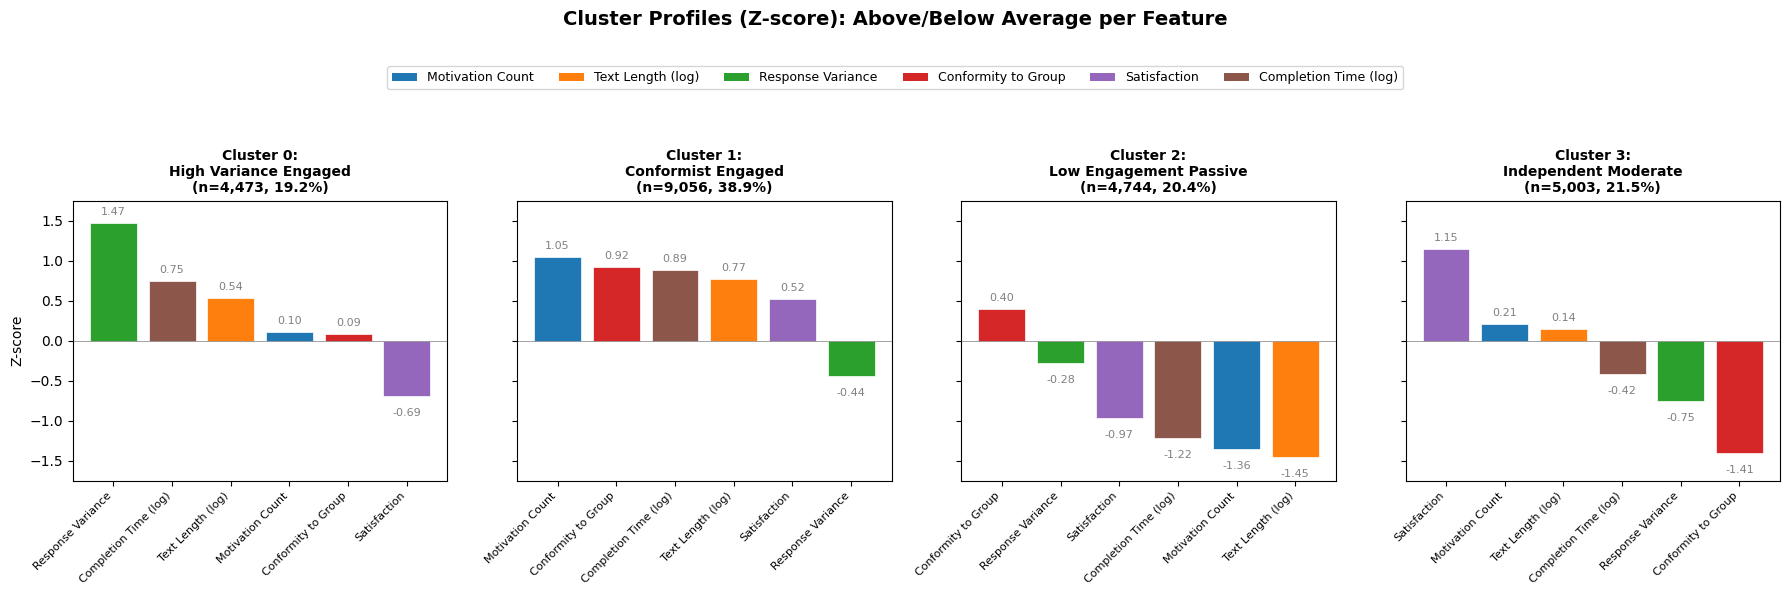

Interpretation: Positive = above average across clusters, Negative = below average


In [161]:
# Cluster names based on interpretation
cluster_names = {
    0: "Cluster 0:\nHigh Variance Engaged",
    1: "Cluster 1:\nConformist Engaged", 
    2: "Cluster 2:\nLow Engagement Passive",
    3: "Cluster 3:\nIndependent Moderate"
}

# Feature display names and colors
feature_labels = {
    "motivationamount": "Motivation Count",
    "logmotivationlength": "Text Length (log)",
    "resp_personal_std": "Response Variance",
    "resp_study_corr": "Conformity to Group",
    "grade": "Satisfaction",
    "log_completion_time": "Completion Time (log)"
}

feature_colors = {
    "motivationamount": "#1f77b4",
    "logmotivationlength": "#ff7f0e",
    "resp_personal_std": "#2ca02c",
    "resp_study_corr": "#d62728",
    "grade": "#9467bd",
    "log_completion_time": "#8c564b"
}

# Z-score normalization (shows how many std deviations from mean)
profile_zscore = cluster_profiles.copy()
for col in cluster_features:
    col_mean = profile_zscore[col].mean()
    col_std = profile_zscore[col].std()
    if col_std > 0:
        profile_zscore[col] = (profile_zscore[col] - col_mean) / col_std
    else:
        profile_zscore[col] = 0

# Fixed y-axis limits
y_min = -1.75
y_max = 1.75

# Create 4 subplots - one per cluster, features ranked high to low
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

n_features = len(cluster_features)

for c in range(n_clusters):
    ax = axes[c]
    
    # Get values for this cluster and sort by descending order
    values = profile_zscore.loc[c, cluster_features].values
    feature_order = np.argsort(values)[::-1]  # Sort high to low
    
    sorted_values = values[feature_order]
    sorted_features = [cluster_features[i] for i in feature_order]
    sorted_labels = [feature_labels[f] for f in sorted_features]
    sorted_colors = [feature_colors[f] for f in sorted_features]
    
    # Plot bars (can be negative with z-score)
    bars = ax.bar(range(n_features), sorted_values, color=sorted_colors, edgecolor="white", linewidth=0.5)
    
    ax.set_xticks(range(n_features))
    ax.set_xticklabels(sorted_labels, fontsize=8, rotation=45, ha="right")
    ax.set_ylabel("Z-score" if c == 0 else "")
    ax.set_title(f"{cluster_names[c]}\n(n={cluster_sizes[c]:,}, {cluster_pcts[c]}%)", fontsize=10, fontweight="bold")
    ax.set_ylim(y_min, y_max)
    ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5, alpha=0.5)
    
    # Add value labels on bars
    for bar, val in zip(bars, sorted_values):
        y_pos = val + 0.1 if val >= 0 else val - 0.25
        ax.annotate(
            f"{val:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, y_pos),
            ha="center",
            fontsize=8,
            color="gray"
        )

# Add legend for features
legend_elements = [plt.Rectangle((0,0), 1, 1, facecolor=feature_colors[f], label=feature_labels[f]) 
                   for f in cluster_features]
fig.legend(handles=legend_elements, loc="upper center", ncol=6, bbox_to_anchor=(0.5, 1.08), fontsize=9)

plt.suptitle("Cluster Profiles (Z-score): Above/Below Average per Feature", fontsize=14, fontweight="bold", y=1.18)
plt.tight_layout()
plt.show()

print("Interpretation: Positive = above average across clusters, Negative = below average")

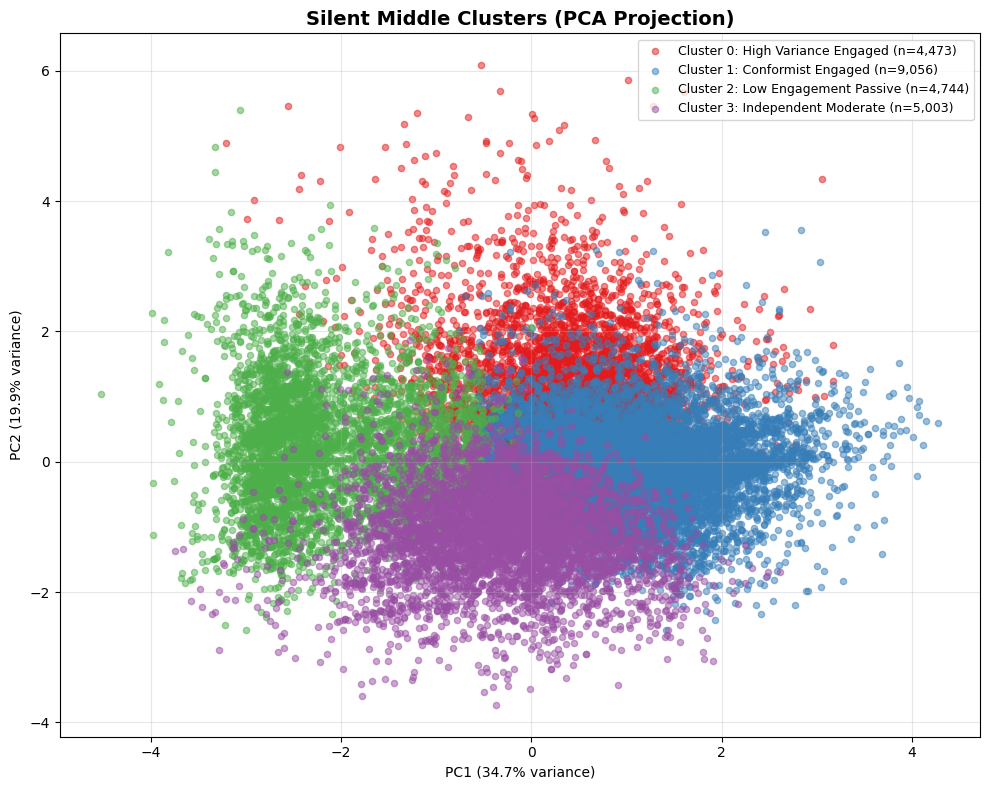

Total variance explained by 2 components: 54.5%


In [162]:
# PCA visualization of clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Cluster colors
cluster_colors_pca = {
    0: "#e41a1c",  # red
    1: "#377eb8",  # blue
    2: "#4daf4a",  # green
    3: "#984ea3"   # purple
}

cluster_labels_pca = {
    0: "High Variance Engaged",
    1: "Conformist Engaged",
    2: "Low Engagement Passive",
    3: "Independent Moderate"
}

fig, ax = plt.subplots(figsize=(10, 8))

for c in range(n_clusters):
    mask = clusters == c
    ax.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1], 
        c=cluster_colors_pca[c], 
        label=f"Cluster {c}: {cluster_labels_pca[c]} (n={mask.sum():,})",
        alpha=0.5,
        s=20
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("Silent Middle Clusters (PCA Projection)", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

### Demographic Profiling

Clusters were formed based on behavioral features only. Now we examine whether clusters differ demographically (age, gender, education).

Demographic Profile by Cluster

AGE distribution:
age       34-  35-64   65+  dont know/wont say
cluster                                       
0        20.1   54.1  25.2                 0.7
1        22.2   48.2  29.1                 0.5
2        32.3   49.5  17.8                 0.4
3        28.5   48.4  22.8                 0.2

GENDER distribution:
gender   male  female  other/wont say
cluster                              
0        64.9    32.6             2.5
1        56.1    42.3             1.6
2        61.5    36.4             2.1
3        50.1    49.1             0.8

EDUCATION distribution:
education   low  middle  high  dont know/wont say
cluster                                          
0           3.2    21.2  74.0                 1.6
1           8.6    24.3  66.1                 1.0
2           8.7    24.9  65.0                 1.4
3          14.5    37.0  47.7                 0.8


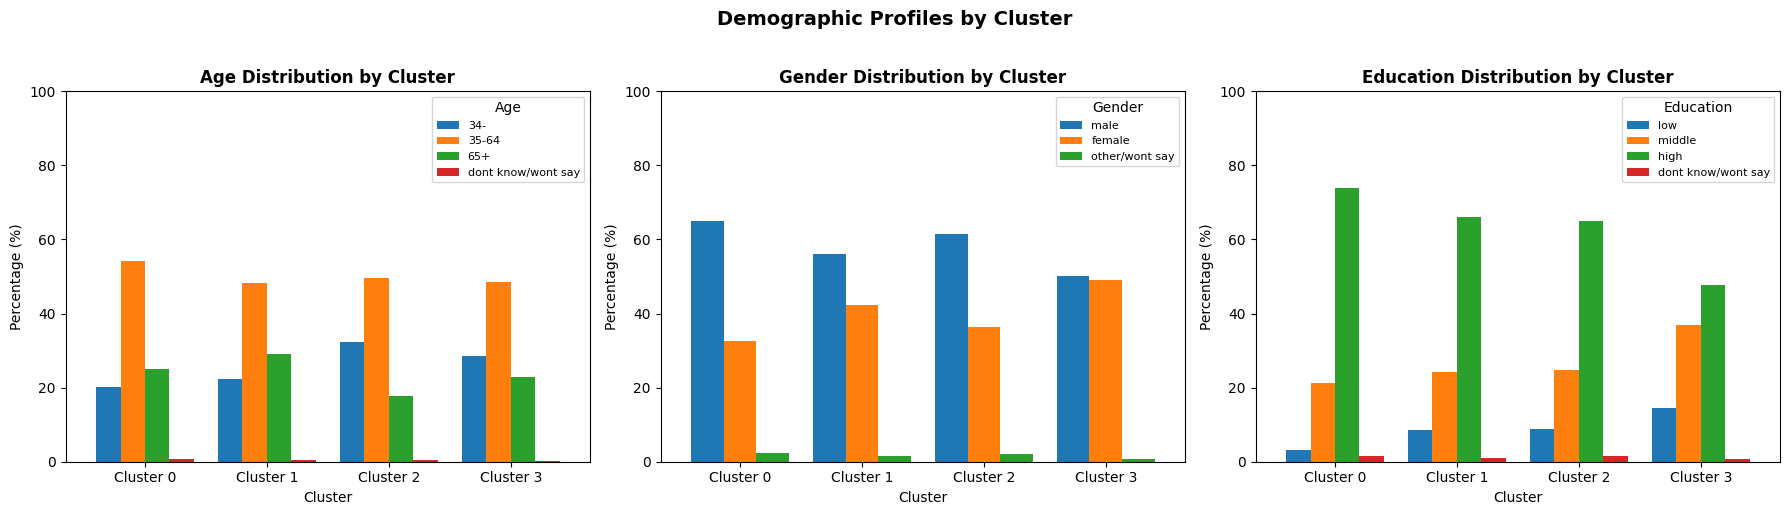


Summary: Dominant demographic per cluster

Cluster 0 (n=4,473):
  age: 35-64 (54.1%)
  gender: male (57.2%)
  education: high (73.8%)

Cluster 1 (n=9,056):
  age: 35-64 (48.2%)
  gender: male (56.0%)
  education: high (60.9%)

Cluster 2 (n=4,744):
  age: 35-64 (49.5%)
  gender: male (61.0%)
  education: high (58.3%)

Cluster 3 (n=5,003):
  age: 35-64 (48.4%)
  gender: male (49.6%)
  education: high (45.6%)


In [163]:
# Demographic profiling of clusters
df_clustered_demo = df_sm.loc[X_cluster.index].copy()
df_clustered_demo["cluster"] = clusters

demo_cols = ["age", "gender", "education"]
demo_cols = [c for c in demo_cols if c in df_clustered_demo.columns]

print("Demographic Profile by Cluster")
print("=" * 80)

# Create one figure with 3 subplots (one per demographic)
fig, axes = plt.subplots(1, len(demo_cols), figsize=(18, 5))

for idx, col in enumerate(demo_cols):
    ax = axes[idx]
    
    # Cross-tabulation with percentages
    ct = pd.crosstab(df_clustered_demo["cluster"], df_clustered_demo[col], normalize="index") * 100
    print(f"\n{col.upper()} distribution:")
    print(ct.round(1))
    
    # Plot grouped bar chart
    ct.plot(kind="bar", ax=ax, width=0.8)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f"{col.title()} Distribution by Cluster", fontsize=12, fontweight="bold")
    ax.legend(title=col.title(), fontsize=8)
    ax.set_xticklabels([f"Cluster {i}" for i in range(n_clusters)], rotation=0)
    ax.set_ylim(0, 100)

plt.suptitle("Demographic Profiles by Cluster", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Summary table with all demographics
print("\n" + "=" * 80)
print("Summary: Dominant demographic per cluster")
print("=" * 80)
for c in range(n_clusters):
    cluster_data = df_clustered_demo[df_clustered_demo["cluster"] == c]
    print(f"\nCluster {c} (n={len(cluster_data):,}):")
    for col in demo_cols:
        mode_val = cluster_data[col].mode()
        if len(mode_val) > 0:
            mode_pct = (cluster_data[col] == mode_val.iloc[0]).mean() * 100
            print(f"  {col}: {mode_val.iloc[0]} ({mode_pct:.1f}%)")

### Cluster Interpretation

Based on the cluster profiles, we identify four distinct subgroups within the silent middle:

| Cluster | Name | Characteristics |
|---------|------|----------------|
| 0 | **High Variance Engaged** | High response variance, engaged with motivations, moderate conformity |
| 1 | **Conformist Engaged** | Highest motivation count, strongly conforms to group median, satisfied |
| 2 | **Low Engagement Passive** | Minimal motivations, low text, quick completion time |
| 3 | **Independent Moderate** | Low conformity to group, consistent responses, highest satisfaction |

**Key Insights:**

1. **Engagement varies widely** - From highly engaged writers (Cluster 1: ~14 motivations) to near-silent participants (Cluster 2: ~1 motivation)

2. **Conformity is independent of engagement** - Cluster 1 writes extensively AND follows the group; Cluster 3 is moderate but independent

3. **Satisfaction correlates with independence** - The most satisfied cluster (3) is also the least conformist

4. **The "silent" middle is not silent** - Most of the silent middle actively provide motivations

This heterogeneity explains why predicting silent middle membership is difficult - the group is defined by outcome (moderate preferences) but arrives there through different behavioral paths.

# Task 4: Name two analytical strengths and two analytical limitations of your selected model and data to predict “the silent middle” group 
## Analytical Strengths
## First Strength:

In our modeling framework, the silent middle is not a naturally occurring group but an artificial construct, which is defined by relative thresholds applied to choice task variables. Consequently, the classification boundary is highly sensitive to the composition of the data. For instance, when looking at the dataset we see that the median value ranges from 0.157 in the 'vrapwe' study to 8.0 in the 'windprovincieutrecht' study. Also there are many different methods used to collect the data (points, sliders, and pick).

The strength of the silent middle lies in the fact that it stays the same even if different methods are used or the same methods are used but deviations vastly differ. If we would have used a single decision tree, it would likely overfit to these study-specific traits. Learning based on the artificial threshold discrepancies rather than genuine behavioral patterns.

This is one reason why the random forest approach is used for our model. By utilizing Bootstrap Aggregating (Bagging), the model constructs an ensemble of trees trained on different data subsets. This process averages out the predictions, effectively smoothing the noise caused by the inconsistent study thresholds and data collection methods, and resulting in a more generalized decision boundary.

## Second Strength:

As mentioned above, our data consists of many different studies, 20 to be exact. This results in a high number of missing values because features available in one study are not used in another. Additionally the dataset describes different data collection methods such as points, sliders, and pick. 

Here lies a crucial analytical strength of the random forest model, because this method does not require scaling. This allows it to handle mixed-type data sets like the one we are using the best. 

# Analytical Limitations
## First Limitation:

While random forest models are formally classified as having 'moderate' interpretability, they represent a significant reduction in transparency compared to the 'easy' interpretability of a single Decision Tree.

In the context of Explainable AI (XAI), shifting to this ensemble method creates a 'black box' risk for socio-technical systems. Although the random forest offers greater stability, we lose the ability to trace a distinct decision path for individual citizens. For instance, while our analysis identifies ‘grade' as the best global predictor (accounting for 15% of feature importance), traditional metrics fail to explain how specific feature combinations result in this silent middle classification. Without applying post-hoc explainability methods like SHAP, we cannot determine the directional impact of these features, creating a risk of misinterpretation by policy makers who require actionable insights.

Furthermore, the model shows a biased preference for the 'silent middle' class, which can be seen in the figure below.

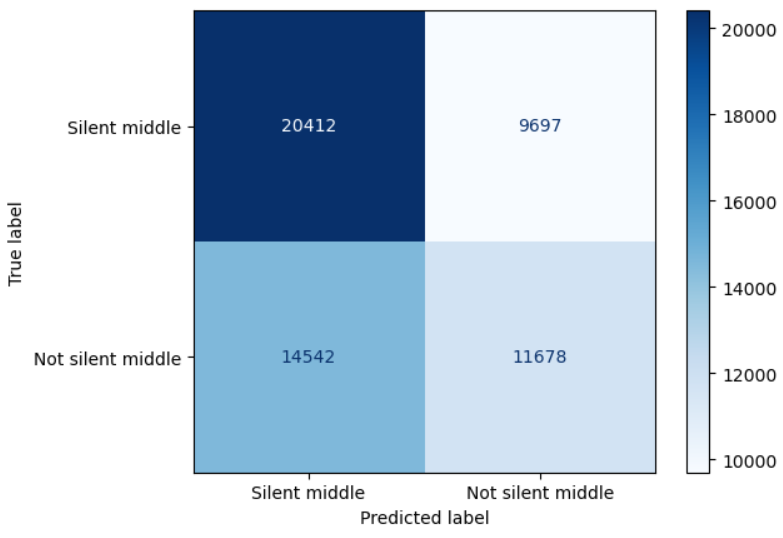

This is corroborated by the model’s medium performance metrics: an ROC AUC of 0.59 indicates the model is performing only slightly better than random chance. Coupling this with a low R^2 score and a correlation matrix that shows little information sharing between features, it is clear that the model lacks predictive power. Consequently, the model’s current usefulness for identifying the silent middle is severely limited.

## Second Limitation:
Exploratory Data Analysis (EDA) revealed that the dataset suffers from significant bias and imbalances, which can be seen in a demographic distribution in the figure below, that differs a lot from the general population.

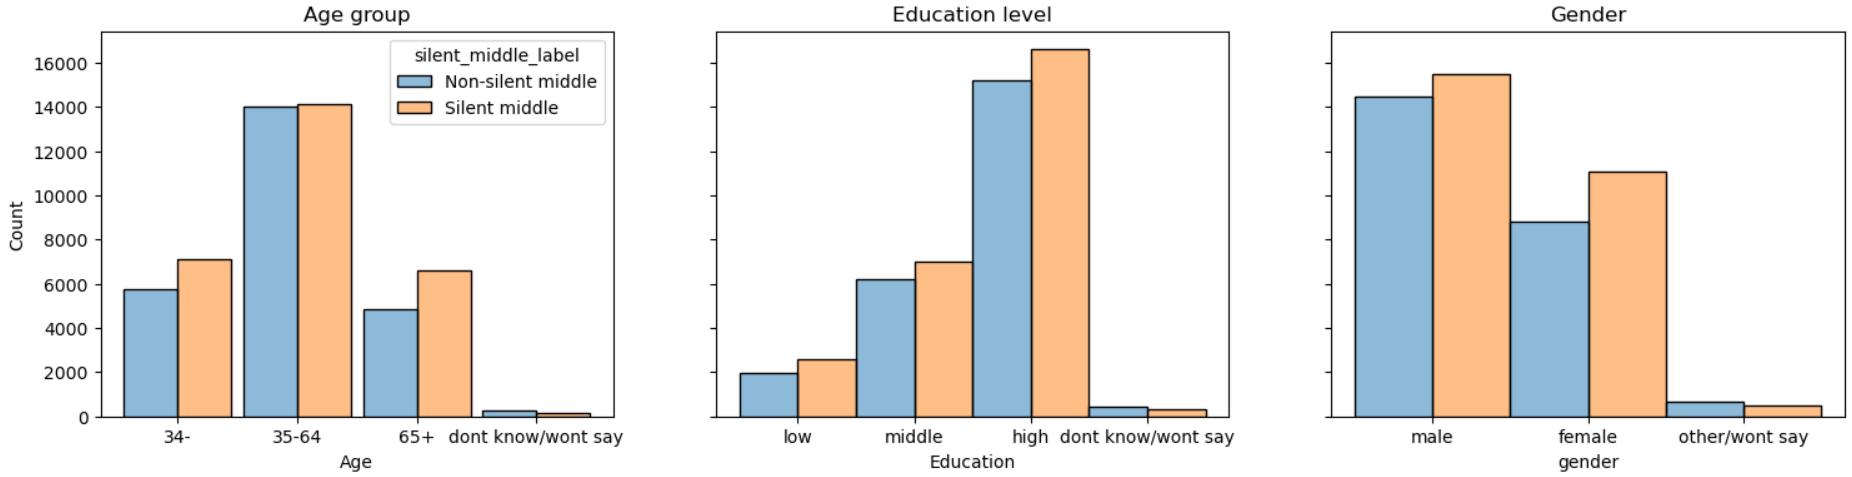

Specifically, the dataset is heavily skewed towards people with high education levels. Also the data has a significant gender imbalance, there is an overrepresentation of males compared to females.

Furthermore, the dataset is compromised by the large number of missing values. Because the data is combined from multiple independent studies there are big gaps in the variables. This combination of demographic imbalances and high data sparsity constitutes a major analytical limitation. It restricts the model’s external validity, any conclusions drawn or predictions made by the model may not be generalizable to the overall society.

# Task 5: Discuss the societal impact of these strengths and limitations on individuals, organisations, and society.
## First Analytical Strength
**Individual Impact**

Because the silent-middle boundary changes according to study, respondents near the threshold are vulnerable to misclassification if the model overfits. By averaging across many trees, Random Forest reduces sensitivity to study-specific noise. This makes individual classifications fairer and more consistent.

**Organisations Impact**

Public organisations use these model outputs to understand citizen preferences and engagement in the survey. If a model overfits to a specific study’s threshold, it may result in producing unreliable insights. Random Forest’s variance reduction makes findings more robust across studies, resulting in more evidence for policy evaluation and reducing the risk that organisations draw incorrect conclusions.

**Society Impact**

By smoothing study-specific noise, Random Forest improves the stability of identifying the silent middle across topics, which supports more balanced democratic interpretation of consultation outcomes

## Second Analytical Strength
**Individual Impact**

respondents do not provide information for all variables, either because certain questions were not asked in their study or because they chose not to answer. Models that require complete and uniformly scaled data could possibly disadvantage such individuals or exclude them from the analysis. By contrast, Random Forest can incorporate imputed values and mixed variable types without distorting individual responses through normalization. This leads to fairer representation of individuals, including those from studies with fewer available features or partial responses.

**Organisations Impact**

For organisations and policymakers, handling missing values and heterogeneous data is a major practical challenge when analyzing large-scale participatory surveys. The ability of Random Forest to work effectively without extensive preprocessing reduces the risk of technical errors and biased results caused by incorrect scaling choices. This makes the model more reliable and easier to deploy in real-world settings, where data is often messy and inconsistent across studies.

**Society Impact**

At the societal level, participatory processes aim to include diverse citizens across different topics and contexts. Models that struggle with missing values or mixed data types risk systematically underrepresenting certain studies. By robustly handling heterogeneous and incomplete data, Random Forest supports inclusive analysis of citizen input across multiple policy domains. This strengthens the legitimacy of data-driven insights used in democratic decision-making.

## First Analytical Limitation
**Individual Impact**

Because the model’s decision-making process is not transparent, individual citizens cannot easily understand why they are classified as part of the silent middle. The absence of clear decision paths means that classifications may appear arbitrary, particularly when the model shows a tendency to assign respondents to the silent middle despite limited predictive certainty. This can reduce fairness and trust among individuals whose participation is being analyzed.

**Organisations Impact**

For organisations and policymakers, limited interpretability combined with moderate predictive performance increases the risk of drawing incorrect conclusions. Without clear explanations, feature importance (such as the dominance of grade) may be mistakenly interpreted as causal, even though the model only captures weak associations. The tendency of the model to favor the silent middle, together with a ROC AUC of only 0.59, suggests that outputs should be used cautiously. Overreliance on such results may lead organisations to design policies or interventions based on misunderstood patterns.

**Society Impact**

At the societal level, the use of black-box models with limited explanatory power in participatory and democratic contexts can undermine transparency and accountability. When citizens and institutions cannot clearly understand or justify AI-driven classifications, trust in data-driven governance may decrease. Furthermore, relying on models with limited predictive strength risks oversimplifying complex social phenomena, potentially leading to misrepresentation of public opinion.

## Second Analytical Limitation
**Individual Impact**

Because the dataset overrepresents certain groups (e.g., highly educated males), individuals from underrepresented groups (such as lower-educated respondents or women) This means their perspectives may be insufficiently reflected in the prediction of the silent middle. Consequently, classifications may be less accurate or less fair for individuals whose characteristics deviate from the dominant profile in the data.

**Organisations Impact**

For organisations and policymakers, a skewed dataset limits the reliability of insights derived from the model. If decision-makers assume that model outputs reflect the broader population, they may design policies that are poorly suited for underrepresented groups. The high level of missing values further complicates interpretation, as predictions are based on incomplete information that varies across studies, increasing uncertainty in decision-making.

**Society Impact**

At the societal level, using a model trained on skewed and incomplete data risks reinforcing existing inequalities in participation and representation. When certain demographic groups dominate the data, AI-supported analyses may implicitly prioritize their perspectives, while marginalizing others. This can undermine the legitimacy of data-driven democratic processes and reduce trust in participatory systems that claim to represent society as a whole.

# Task 6: Propose a potential analytical solution (related to model or data) for mitigating the most severe limitation.
The most severe limitation identified is the dataset’s overrepresentation of highly educated people and imbalance in gender, we believe this causes the model’s bias towards the silent middle class. 

In the normal random forest approach, the model attempts to minimize overall error. Misclassifying a person from the majority group (e.g., high education) is treated as equal to misclassifying a person from a minority group (e.g., low education). Because the majority group is larger, the model prioritizes them to achieve a higher "accuracy" score

To mitigate this limitation without collecting new data, we can apply the idea of cost sensitive learning. In the paper of Chen et al. (2004), higher weights (panelties) are assigned to underrepresented demographic groups and minority classes, while the overrepresented group gets a lower weight assigned. 

By applying this weighted random forest approach to our dataset, we expect improvements with a significant reduction in the models' bias toward the dominant silent middle class and highly educated demographic groups. This switch to a more “fair” random forest model can help with improving the model’s external validity and fairness regarding underrepresented groups.




#### References

Chen, C., Liaw, A., & Breiman, L. (2004). Using random forest to learn imbalanced data (Tech. Rep. No. 666). Department of Statistics, University of California, Berkeley. https://statistics.berkeley.edu/sites/default/files/tech-reports/666.pdf

### AI Disclosure

AI was used for several tasks:
- Spelling checks
- Improving code
- Advise on modelling steps

The following AI programs were used:
- ChatGPT: Improving code, Modelling advice, Spelling checks
- Claude: Improving code

Example Usage Prompt:
I am currently making a model which identifies a group across several studies that has modest views. The target variable 'Silent middle' is a constructed variable which aims to capture this group with modest views. It is a random forest model which attempts to predict the silent middle on certain demographic and opinion variables, however the model has a low r2 and fairly weak predictive performance. What could be good scoring metrics that might reflect the modelling better than r2?